# Chapter 19: Export Systems and Fiscal Metering

**Production Optimization of Oil and Gas Fields Using NeqSim**

This notebook demonstrates export system modeling including:
- Gas export pipeline modeling with Beggs and Brill correlation
- Pressure and temperature profiles along the pipeline
- Gas quality calculations (heating value, Wobbe index concept)
- Sensitivity to pipeline length and diameter

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch17_export_metering.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 1. Gas Export Pipeline Model

We model a subsea gas export pipeline from an offshore platform to
an onshore receiving terminal. The pipeline is 150 km long, 24-inch
diameter, with the Beggs and Brill multiphase correlation.

The export gas is a lean, processed natural gas after separation
and dehydration.

In [2]:
# jneqsim is bound to the source JVM in the setup cell.

# Export gas composition (processed, dehydrated)
export_gas = jneqsim.thermo.system.SystemSrkEos(273.15 + 40.0, 180.0)
export_gas.addComponent("nitrogen", 1.5)
export_gas.addComponent("CO2", 2.0)
export_gas.addComponent("methane", 85.0)
export_gas.addComponent("ethane", 7.0)
export_gas.addComponent("propane", 3.0)
export_gas.addComponent("i-butane", 0.8)
export_gas.addComponent("n-butane", 0.7)
export_gas.setMixingRule("classic")

# Feed stream
feed = jneqsim.process.equipment.stream.Stream("Export Gas", export_gas)
feed.setFlowRate(5.0e6, "Sm3/day")  # 5 MSm3/day
feed.setTemperature(40.0, "C")
feed.setPressure(180.0, "bara")

# Export pipeline - 150 km, 24-inch, horizontal subsea
pipeline = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills("Export Pipeline", feed)
pipeline.setLength(150000.0)  # 150 km
pipeline.setElevation(0.0)    # horizontal (subsea)
pipeline.setDiameter(0.5588)  # 24 inch = 0.5588 m
pipeline.setPipeWallRoughness(4.5e-5)
pipeline.setNumberOfIncrements(30)
pipeline.setConstantSurfaceTemperature(4.0, "C")  # seabed temperature

process = jneqsim.process.processmodel.ProcessSystem()
process.add(feed)
process.add(pipeline)
process.run()
assert _physics.run(process, 'calculation_cell_3:process', candidate=False)

print("=== Gas Export Pipeline Results ===")
print(f"Pipeline length:       150 km")
print(f"Pipeline ID:           24 inch (558.8 mm)")
print(f"Inlet pressure:        {feed.getPressure('bara'):.1f} bara")
print(f"Outlet pressure:       {pipeline.getOutletStream().getPressure('bara'):.1f} bara")
print(f"Total pressure drop:   {pipeline.getPressureDrop():.1f} bar")
print(f"Inlet temperature:     {feed.getTemperature('C'):.1f} C")
print(f"Outlet temperature:    {pipeline.getOutletStream().getTemperature('C'):.1f} C")


=== Gas Export Pipeline Results ===
Pipeline length:       150 km
Pipeline ID:           24 inch (558.8 mm)
Inlet pressure:        180.0 bara
Outlet pressure:       177.2 bara
Total pressure drop:   2.8 bar
Inlet temperature:     40.0 C
Outlet temperature:    4.0 C


## 2. Pressure and Temperature Profiles Along Pipeline

The `PipeBeggsAndBrills` model computes profiles at each increment.
We extract and plot the pressure and temperature along the pipeline length.

Figure saved to ../figures/ch17_pipeline_profiles.png


ch17_export_metering.ipynb:cell5:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


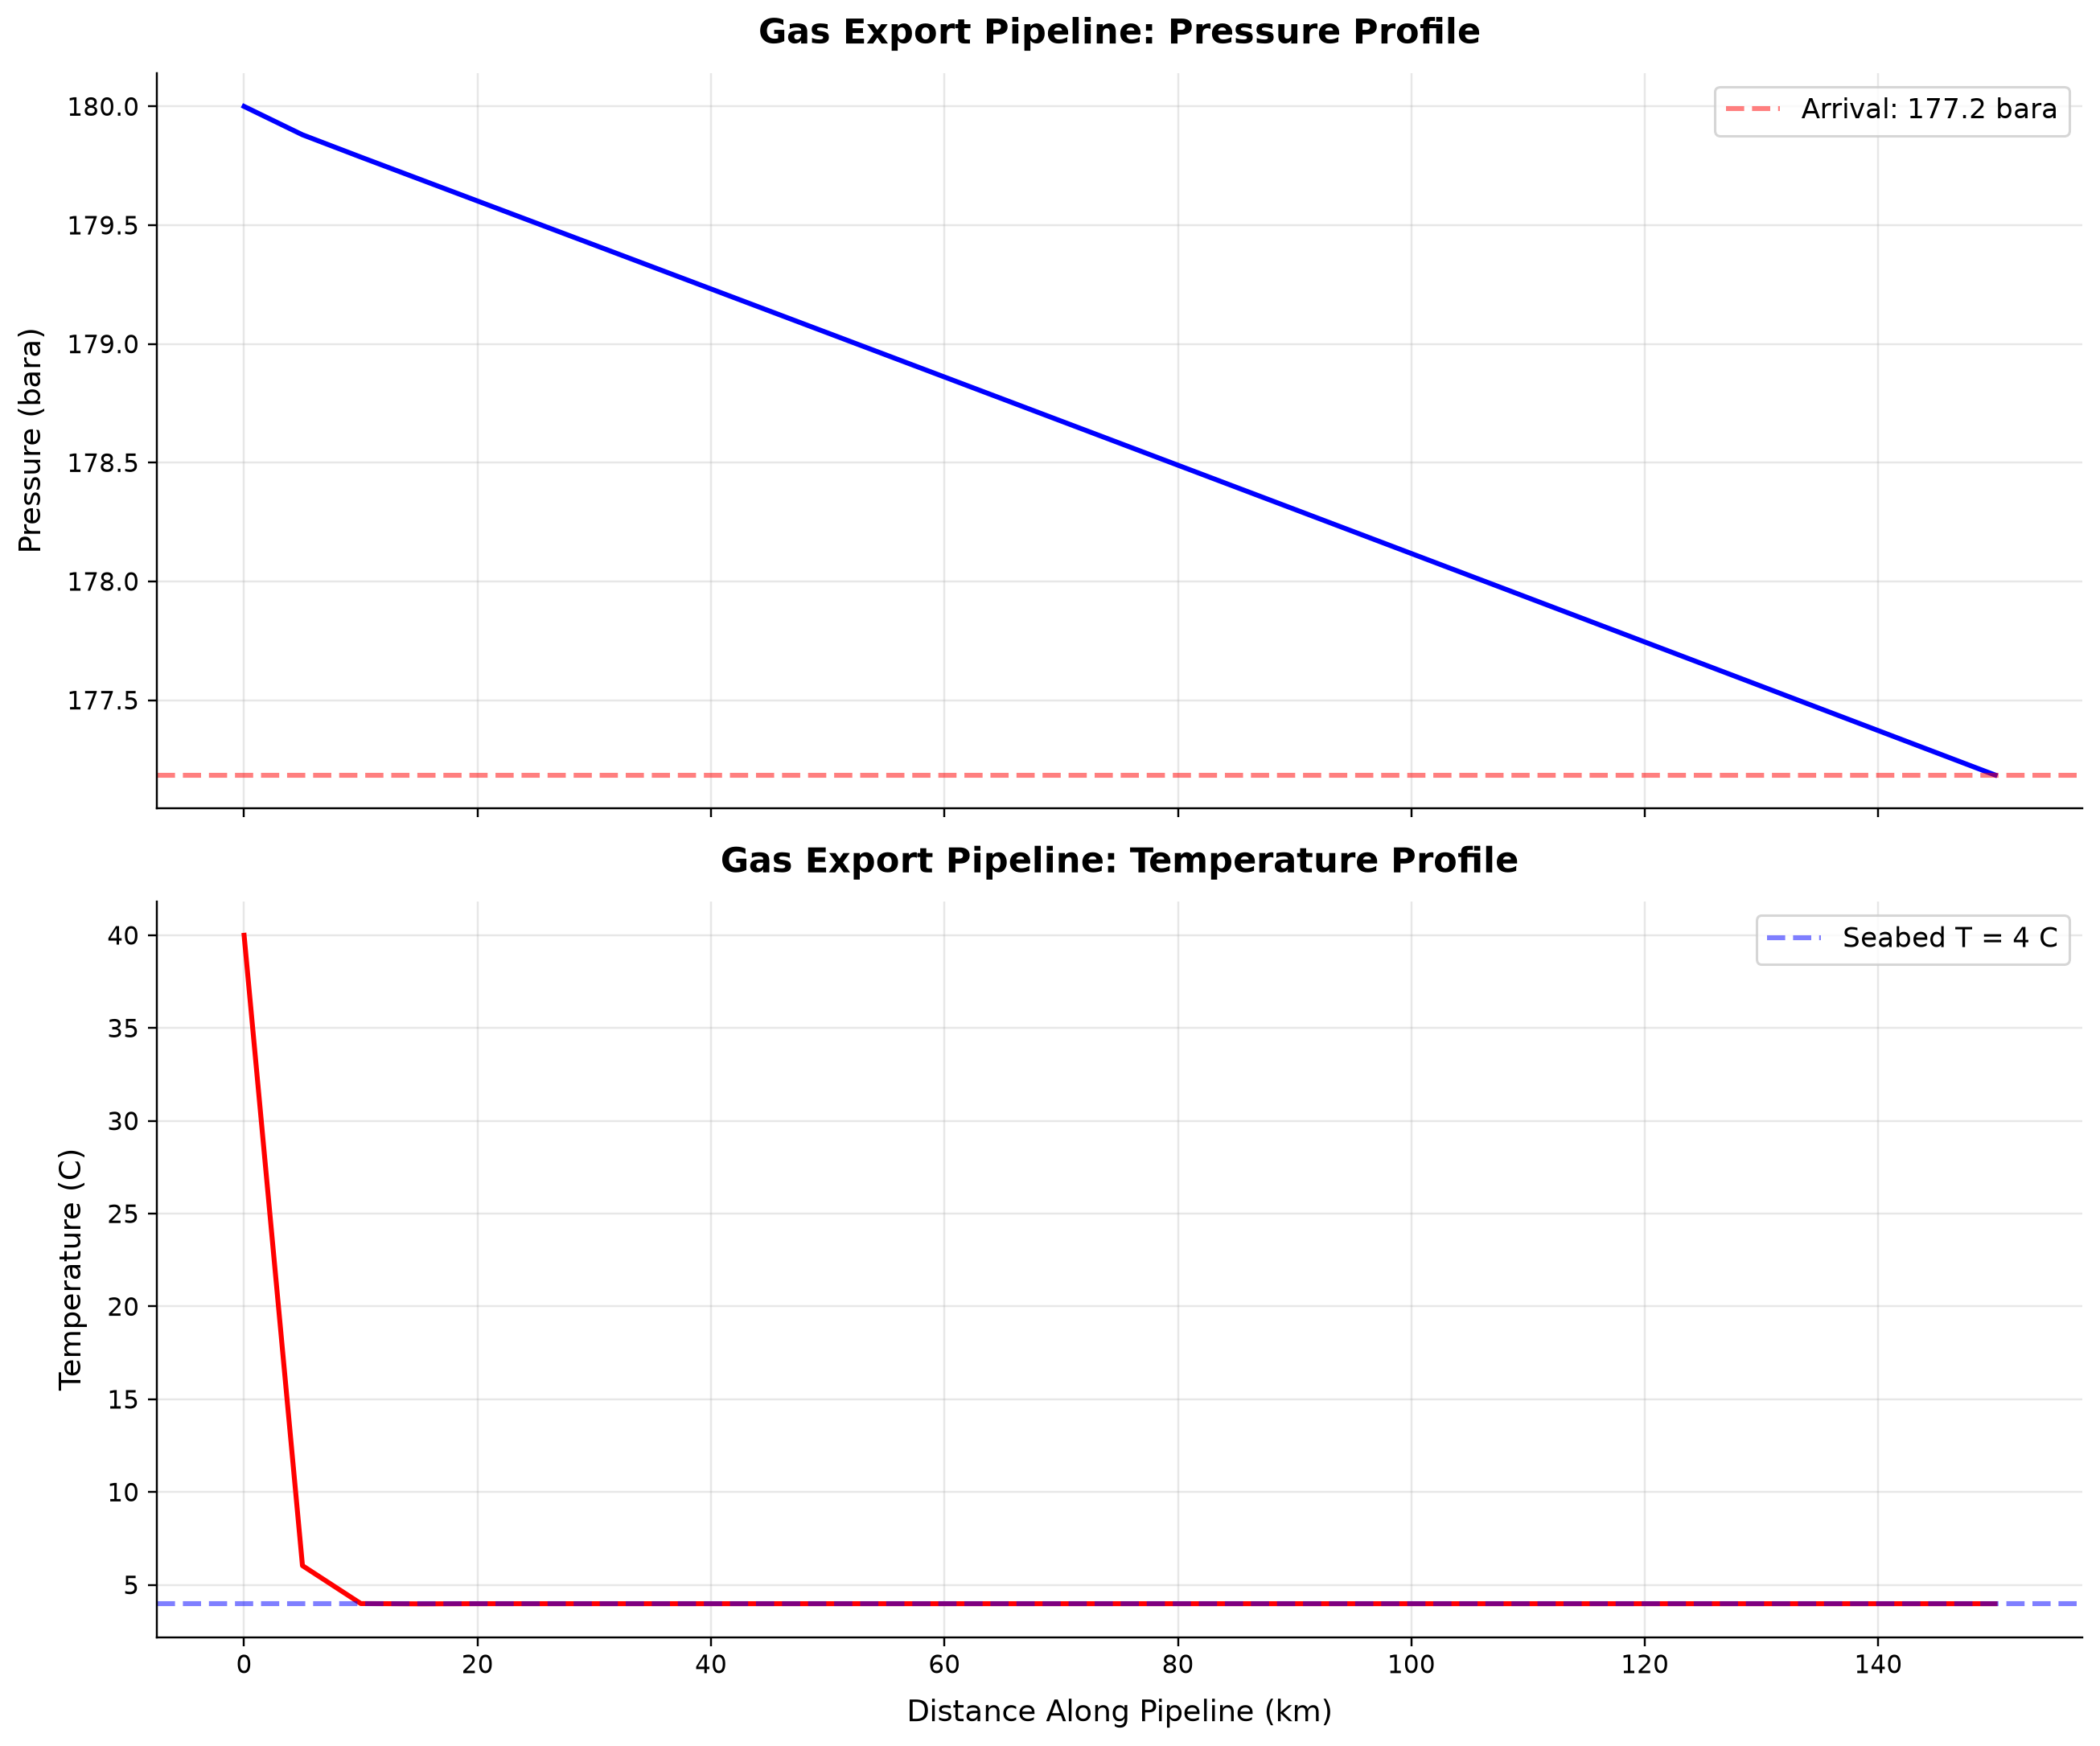

In [3]:
# Extract profiles
pressure_profile = list(pipeline.getPressureProfile())
temperature_profile = list(pipeline.getTemperatureProfile())

# Convert temperature from K to C
temperature_profile_C = [t - 273.15 for t in temperature_profile]

# Distance along pipeline (km)
n_points = len(pressure_profile)
distance_km = np.linspace(0, 150, n_points)

# Plot pressure profile
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(distance_km, pressure_profile, 'b-', linewidth=2)
ax1.set_ylabel("Pressure (bara)", fontsize=12)
ax1.set_title("Gas Export Pipeline: Pressure Profile", fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=pressure_profile[-1], color='r', linestyle='--', alpha=0.5,
            label=f"Arrival: {pressure_profile[-1]:.1f} bara")
ax1.legend(fontsize=11)

ax2.plot(distance_km, temperature_profile_C, 'r-', linewidth=2)
ax2.axhline(y=4.0, color='blue', linestyle='--', alpha=0.5, label="Seabed T = 4 C")
ax2.set_xlabel("Distance Along Pipeline (km)", fontsize=12)
ax2.set_ylabel("Temperature (C)", fontsize=12)
ax2.set_title("Gas Export Pipeline: Temperature Profile", fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch17_pipeline_profiles.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved to ../figures/ch17_pipeline_profiles.png")


**Executed-figure discussion.** Pressure spans 177.2–180 bara across the plotted cases. Temperature spans 3.978–40 C across the plotted cases.

Friction reduces pressure along the line, while the specified surroundings remove sensible heat. The small pressure loss in this case does not imply a large thermal margin: the outlet approaches the ambient temperature. Evaluate low-rate and shutdown thermal conditions separately before choosing insulation or inhibition.


## 3. Gas Quality Calculations

For fiscal metering and gas sales, key quality parameters include:
- **Gross Heating Value (GHV)** — energy content per unit volume
- **Wobbe Index** — interchangeability criterion for gas burners
- **Relative Density** (specific gravity)

We compute these from the thermodynamic properties of the export gas.

In [4]:
# Gas quality at standard conditions (15 C, 1.01325 bara)
gas_std = jneqsim.thermo.system.SystemSrkEos(273.15 + 15.0, 1.01325)
gas_std.addComponent("nitrogen", 1.5)
gas_std.addComponent("CO2", 2.0)
gas_std.addComponent("methane", 85.0)
gas_std.addComponent("ethane", 7.0)
gas_std.addComponent("propane", 3.0)
gas_std.addComponent("i-butane", 0.8)
gas_std.addComponent("n-butane", 0.7)
gas_std.setMixingRule("classic")

ops = jneqsim.thermodynamicoperations.ThermodynamicOperations(gas_std)
ops.TPflash()
gas_std.initProperties()
assert _physics.state(gas_std, 'calculation_cell_7:gas_std', candidate=False)

# Get molar mass and density
molar_mass = gas_std.getMolarMass() * 1000.0  # kg/kmol
gas_density = gas_std.getDensity("kg/m3")

# Air properties at standard conditions for relative density
air_molar_mass = 28.97  # kg/kmol
relative_density = molar_mass / air_molar_mass

# ISO 6976: 15 C combustion and metering temperatures, volume basis.
iso = jneqsim.standards.gasquality.Standard_ISO6976(gas_std, 15.0, 15.0, "volume")
iso.calculate()
ghv = float(iso.getValue("SuperiorCalorificValue")) / 1000.0
wobbe_index = float(iso.getValue("SuperiorWobbeIndex")) / 1000.0
relative_density = float(iso.getValue("RelativeDensity"))

print("=== Gas Quality at Standard Conditions (15 C, 1.01325 bara) ===")
print(f"Molar mass:        {molar_mass:.2f} kg/kmol")
print(f"Gas density:       {gas_density:.4f} kg/m3")
print(f"Relative density:  {relative_density:.4f}")
print(f"Gross Heating Value: {ghv:.2f} MJ/Sm3")
print(f"Wobbe Index:       {wobbe_index:.2f} MJ/Sm3")
print()
print("Illustrative gas-quality screening limits (not a contract):")
print(f"  GHV:    36-42 MJ/Sm3  -> {'PASS' if 36 <= ghv <= 42 else 'FAIL'}")
print(f"  Wobbe:  46-52 MJ/Sm3  -> {'PASS' if 46 <= wobbe_index <= 52 else 'CHECK'}")


=== Gas Quality at Standard Conditions (15 C, 1.01325 bara) ===
Molar mass:        19.24 kg/kmol
Gas density:       0.8158 kg/m3
Relative density:  0.6657
Gross Heating Value: 41.43 MJ/Sm3
Wobbe Index:       50.78 MJ/Sm3

Illustrative gas-quality screening limits (not a contract):
  GHV:    36-42 MJ/Sm3  -> PASS
  Wobbe:  46-52 MJ/Sm3  -> PASS


## 4. Pipeline Diameter Sensitivity

Pipeline sizing is a critical design decision balancing CAPEX
(larger pipe = more material cost) against OPEX (smaller pipe = more
compression energy). We study pipe diameters from 18 to 36 inches.

In [5]:
# Pipe diameter sensitivity
diameters_inch = [18, 20, 22, 24, 26, 28, 30, 32, 34, 36]
diameters_m = [d * 0.0254 for d in diameters_inch]
pressure_drops = []
arrival_pressures = []
arrival_temperatures = []

for d_m in diameters_m:
    gas_i = jneqsim.thermo.system.SystemSrkEos(273.15 + 40.0, 180.0)
    gas_i.addComponent("nitrogen", 1.5)
    gas_i.addComponent("CO2", 2.0)
    gas_i.addComponent("methane", 85.0)
    gas_i.addComponent("ethane", 7.0)
    gas_i.addComponent("propane", 3.0)
    gas_i.addComponent("i-butane", 0.8)
    gas_i.addComponent("n-butane", 0.7)
    gas_i.setMixingRule("classic")

    feed_i = jneqsim.process.equipment.stream.Stream("Feed", gas_i)
    feed_i.setFlowRate(5.0e6, "Sm3/day")
    feed_i.setTemperature(40.0, "C")
    feed_i.setPressure(180.0, "bara")

    pipe_i = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills("Pipeline", feed_i)
    pipe_i.setLength(150000.0)
    pipe_i.setElevation(0.0)
    pipe_i.setDiameter(d_m)
    pipe_i.setPipeWallRoughness(4.5e-5)
    pipe_i.setNumberOfIncrements(20)
    pipe_i.setConstantSurfaceTemperature(4.0, "C")

    proc_i = jneqsim.process.processmodel.ProcessSystem()
    proc_i.add(feed_i)
    proc_i.add(pipe_i)
    proc_i.run()
    assert _physics.run(proc_i, 'calculation_cell_9:proc_i', candidate=False)

    dp = pipe_i.getPressureDrop()
    p_arrival = pipe_i.getOutletStream().getPressure("bara")
    t_arrival = pipe_i.getOutletStream().getTemperature("C")

    pressure_drops.append(dp)
    arrival_pressures.append(p_arrival)
    arrival_temperatures.append(t_arrival)

print(f"{'Diameter (inch)':<18} {'dP (bar)':<12} {'P_arrival (bara)':<18} {'T_arrival (C)'}")
print("-" * 62)
for i, d in enumerate(diameters_inch):
    print(f"{d:<18} {pressure_drops[i]:<12.1f} {arrival_pressures[i]:<18.1f} {arrival_temperatures[i]:.1f}")


Diameter (inch)    dP (bar)     P_arrival (bara)   T_arrival (C)
--------------------------------------------------------------
18                 8.0          172.0              3.9
20                 4.6          175.4              4.0
22                 2.8          177.2              4.0
24                 1.8          178.2              4.0
26                 1.2          178.8              4.0
28                 0.8          179.2              4.0
30                 0.6          179.4              4.0
32                 0.4          179.6              4.0
34                 0.3          179.7              4.0
36                 0.2          179.8              4.0


Figure saved to ../figures/ch17_diameter_sensitivity.png


ch17_export_metering.ipynb:cell10:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


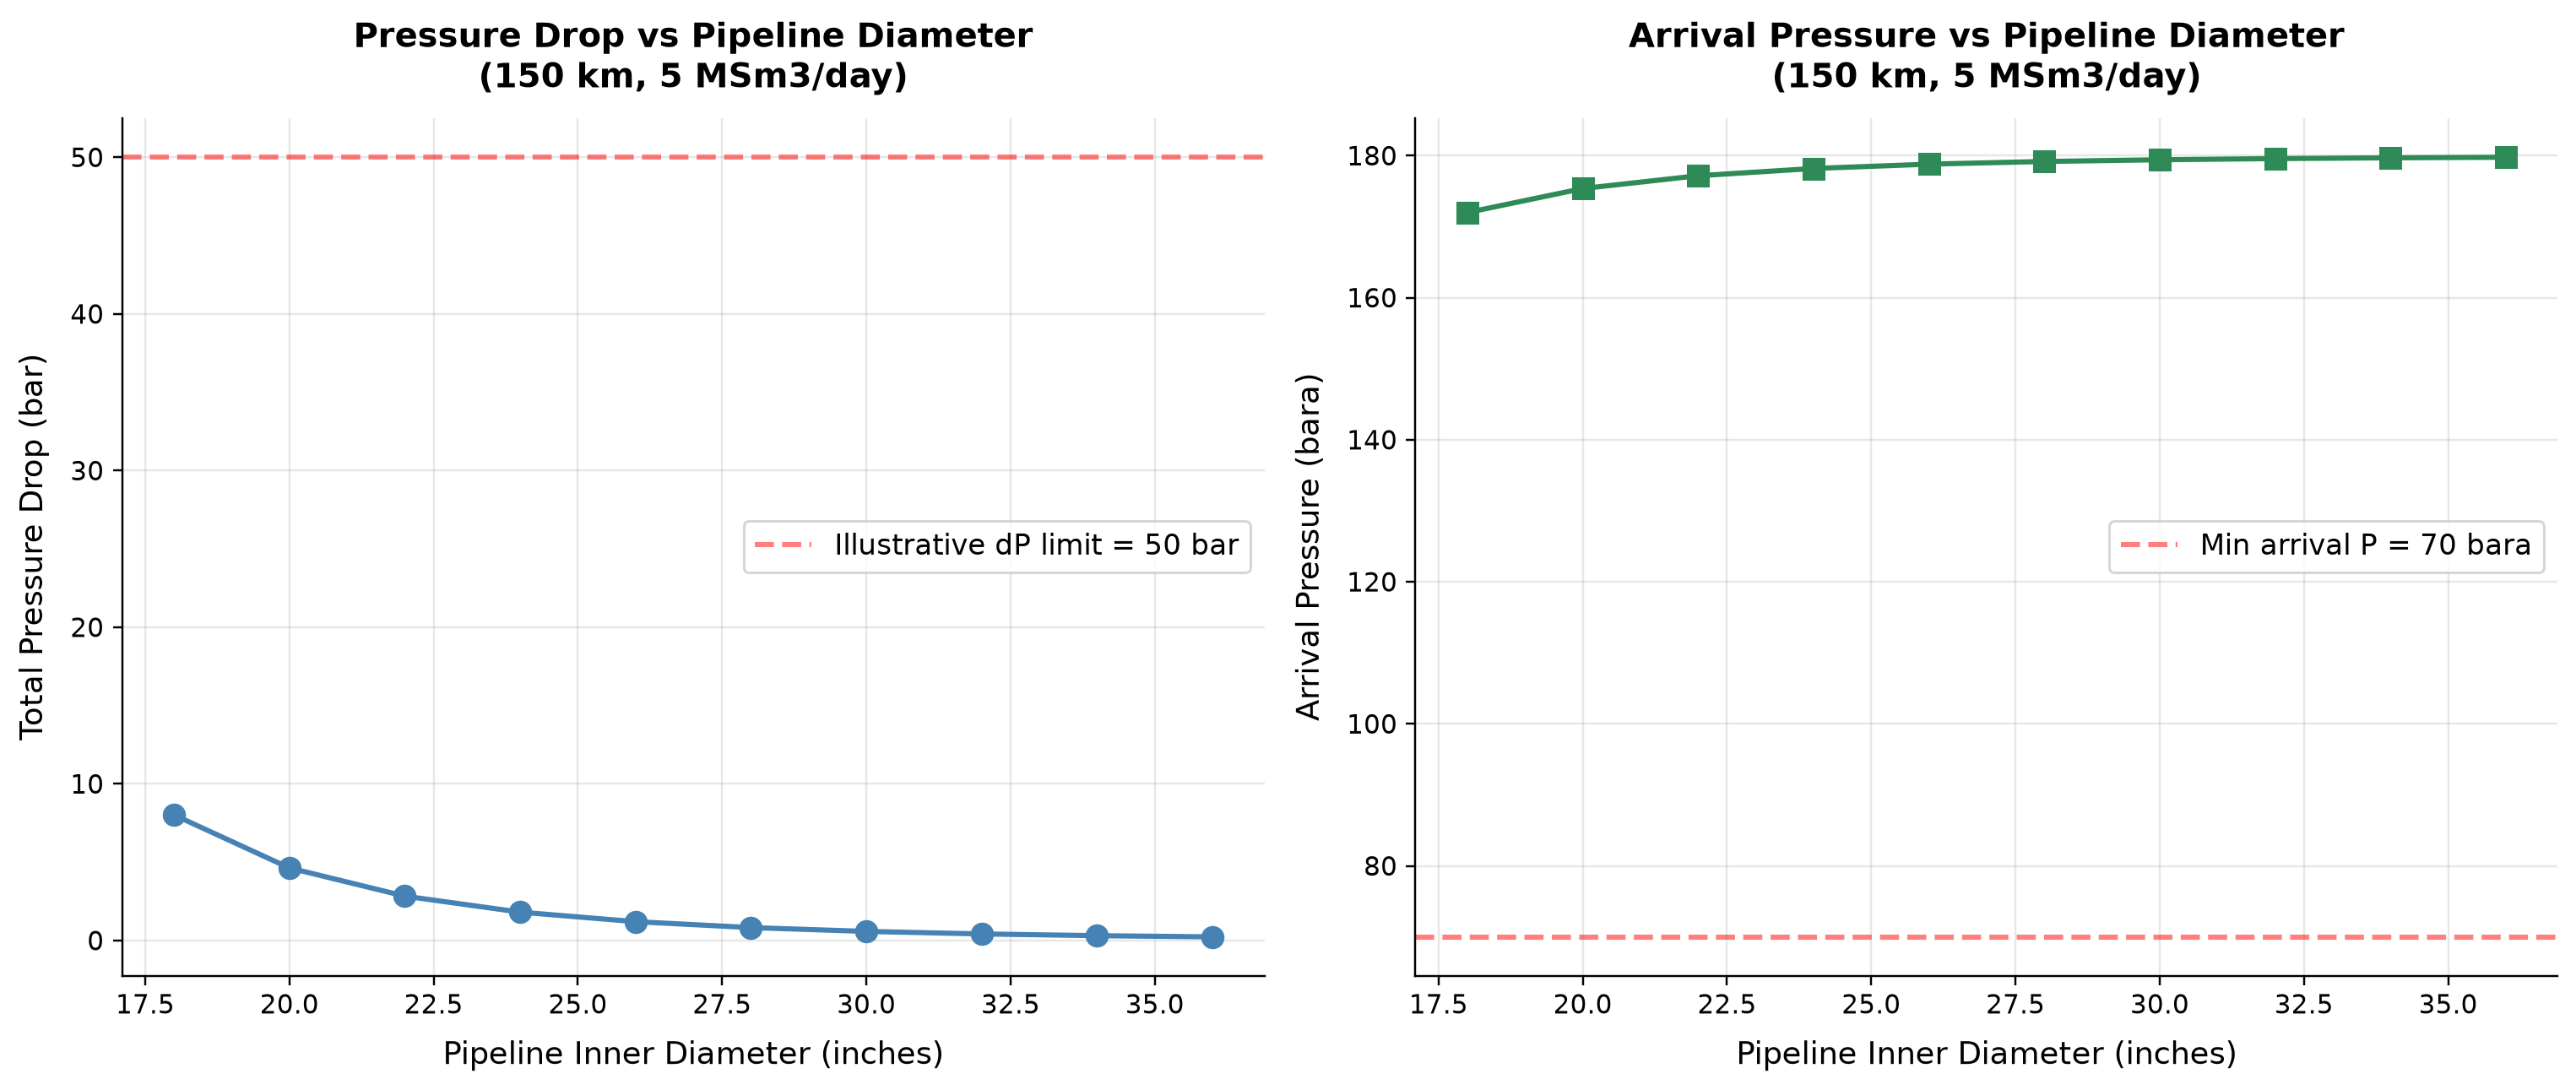

In [6]:
# Plot: Pressure drop and arrival pressure vs diameter
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(diameters_inch, pressure_drops, 'o-', color="steelblue", linewidth=2, markersize=8)
ax1.set_xlabel("Pipeline Inner Diameter (inches)", fontsize=12)
ax1.set_ylabel("Total Pressure Drop (bar)", fontsize=12)
ax1.set_title("Pressure Drop vs Pipeline Diameter\n(150 km, 5 MSm3/day)", fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=50, color='r', linestyle='--', alpha=0.5, label="Illustrative dP limit = 50 bar")
ax1.legend(fontsize=11)

ax2.plot(diameters_inch, arrival_pressures, 's-', color="seagreen", linewidth=2, markersize=8)
ax2.set_xlabel("Pipeline Inner Diameter (inches)", fontsize=12)
ax2.set_ylabel("Arrival Pressure (bara)", fontsize=12)
ax2.set_title("Arrival Pressure vs Pipeline Diameter\n(150 km, 5 MSm3/day)", fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=70, color='r', linestyle='--', alpha=0.5, label="Min arrival P = 70 bara")
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch17_diameter_sensitivity.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved to ../figures/ch17_diameter_sensitivity.png")


**Executed-figure discussion.** Total Pressure Drop spans 0.2295–8.012 bar across the plotted cases. Arrival Pressure spans 172–179.8 bara across the plotted cases.

Increasing diameter reduces phase velocity and friction for the fixed export rate. The hydraulic benefit diminishes as the pressure loss becomes small compared with the available pressure. Compare the incremental pressure saving with pipe and installation cost on the same route basis.


## Discussion

**Pressure Profile:** The pressure decreases nearly linearly along the pipeline
for single-phase gas flow. The slight non-linearity comes from gas expansion
reducing density (and velocity) along the length, which decreases frictional
losses per unit length downstream.

**Temperature Profile:** The gas cools from 40 C toward the seabed temperature
(4 C) as heat is lost through the pipe wall. The cooling is most rapid in the
first 30-40 km where the temperature difference is largest, following an
exponential decay pattern.

**Gas Quality:** The Gross Heating Value and Wobbe Index confirm the export gas
meets typical sales specifications. These parameters are critical for fiscal
metering and tariff calculations. CO2 and N2 are diluents that reduce heating
value and must be controlled.

**Pipeline Sizing:** Pressure drop is extremely sensitive to diameter — it
decreases roughly with the 5th power of diameter. Smaller pipelines (18-20")
may have unacceptable pressure losses for 5 MSm3/day throughput, while
larger pipelines (30-36") offer diminishing returns. The optimal size balances
CAPEX against the required inlet compression to maintain arrival pressure
above the minimum delivery specification.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [7]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                       Figure  Panel                         Series             Output / unit  Minimum  Maximum  Finite points  Missing points
   ch17_pipeline_profiles.png      1                        Curve 1           Pressure (bara)  177.185      180             31               0
   ch17_pipeline_profiles.png      1            Arrival: 177.2 bara           Pressure (bara)  177.185  177.185              2               0
   ch17_pipeline_profiles.png      2                        Curve 1           Temperature (C)  3.97816       40             31               0
   ch17_pipeline_profiles.png      2                 Seabed T = 4 C           Temperature (C)        4        4              2               0
ch17_diameter_sensitivity.png      1                        Curve 1 Total Pressure Drop (bar) 0.229518  8.01211             10               0
ch17_diameter_sensitivity.png      1 Illustrative dP limit = 50 bar Total Pressure Drop (bar)       50       50              2               0

## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [8]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 124 distinct checks, 529 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

Export hydraulics and calorific-value unit basis. ISO calculator execution is not custody-transfer certification or metering uncertainty validation.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
